In [1]:
# ==================== 1. INSTALL & IMPORT ====================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

# For later modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

print("✅ Libraries imported successfully!")

# ==================== 2. LOAD THE DATA ====================
# Upload your file first: Files → Upload → ocd_patient_dataset.csv
df = pd.read_csv('ocd_patient_dataset.csv')

print("Shape of dataset:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
display(df.head(3))

✅ Libraries imported successfully!
Shape of dataset: (1500, 17)

Columns: ['Patient ID', 'Age', 'Gender', 'Ethnicity', 'Marital Status', 'Education Level', 'OCD Diagnosis Date', 'Duration of Symptoms (months)', 'Previous Diagnoses', 'Family History of OCD', 'Obsession Type', 'Compulsion Type', 'Y-BOCS Score (Obsessions)', 'Y-BOCS Score (Compulsions)', 'Depression Diagnosis', 'Anxiety Diagnosis', 'Medications']

First 3 rows:


,Patient ID,Age,Gender,Ethnicity,Marital Status,Education Level,OCD Diagnosis Date,Duration of Symptoms (months),Previous Diagnoses,Family History of OCD,Obsession Type,Compulsion Type,Y-BOCS Score (Obsessions),Y-BOCS Score (Compulsions),Depression Diagnosis,Anxiety Diagnosis,Medications
0,1018,32,Female,African,Single,Some College,2016-07-15,203,MDD,No,Harm-related,Checking,17,10,Yes,Yes,SNRI
1,2406,69,Male,African,Divorced,Some College,2017-04-28,180,NaN,Yes,Harm-related,Washing,21,25,Yes,Yes,SSRI
2,1188,57,Male,Hispanic,Divorced,College Degree,2018-02-02,173,MDD,No,Contamination,Checking,3,4,No,No,Benzodiazepine


In [2]:
# ==================== FULL PREPROCESSING ====================

# 1. Drop irrelevant column
df = df.drop(columns=['Patient ID'], errors='ignore')

# 2. Convert date column
df['OCD Diagnosis Date'] = pd.to_datetime(df['OCD Diagnosis Date'], errors='coerce')

# 3. Create useful new features
df['Diagnosis_Year'] = df['OCD Diagnosis Date'].dt.year
df['Total_YBOCS'] = df['Y-BOCS Score (Obsessions)'] + df['Y-BOCS Score (Compulsions)']

# Severity Level (Clinical standard)
def get_severity(score):
    if score <= 7: return 'Subclinical'
    elif score <= 15: return 'Mild'
    elif score <= 23: return 'Moderate'
    elif score <= 31: return 'Severe'
    else: return 'Extreme'

df['Severity_Level'] = df['Total_YBOCS'].apply(get_severity)

# 4. Handle "None" values properly
df['Previous Diagnoses'] = df['Previous Diagnoses'].fillna('None')
df['Medications'] = df['Medications'].fillna('None')

# 5. Binary encoding for Yes/No columns
binary_cols = ['Family History of OCD', 'Depression Diagnosis', 'Anxiety Diagnosis']
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map({'Yes': 1, 'No': 0, 'yes':1, 'no':0})

print("✅ Preprocessing completed!")
print("New shape:", df.shape)
print("\nNew columns created:", ['Diagnosis_Year', 'Total_YBOCS', 'Severity_Level'])
display(df.head())

✅ Preprocessing completed!
New shape: (1500, 19)

New columns created: ['Diagnosis_Year', 'Total_YBOCS', 'Severity_Level']


,Age,Gender,Ethnicity,Marital Status,Education Level,OCD Diagnosis Date,Duration of Symptoms (months),Previous Diagnoses,Family History of OCD,Obsession Type,Compulsion Type,Y-BOCS Score (Obsessions),Y-BOCS Score (Compulsions),Depression Diagnosis,Anxiety Diagnosis,Medications,Diagnosis_Year,Total_YBOCS,Severity_Level
0,32,Female,African,Single,Some College,2016-07-15,203,MDD,0,Harm-related,Checking,17,10,1,1,SNRI,2016,27,Severe
1,69,Male,African,Divorced,Some College,2017-04-28,180,None,1,Harm-related,Washing,21,25,1,1,SSRI,2017,46,Extreme
2,57,Male,Hispanic,Divorced,College Degree,2018-02-02,173,MDD,0,Contamination,Checking,3,4,0,0,Benzodiazepine,2018,7,Subclinical
3,27,Female,Hispanic,Married,College Degree,2014-08-25,126,PTSD,1,Symmetry,Washing,14,28,1,1,SSRI,2014,42,Extreme
4,56,Female,Hispanic,Married,High School,2022-02-20,168,PTSD,1,Hoarding,Ordering,39,18,0,0,None,2022,57,Extreme


Missing Values:
 Age                              0
Gender                           0
Ethnicity                        0
Marital Status                   0
Education Level                  0
OCD Diagnosis Date               0
Duration of Symptoms (months)    0
Previous Diagnoses               0
Family History of OCD            0
Obsession Type                   0
Compulsion Type                  0
Y-BOCS Score (Obsessions)        0
Y-BOCS Score (Compulsions)       0
Depression Diagnosis             0
Anxiety Diagnosis                0
Medications                      0
Diagnosis_Year                   0
Total_YBOCS                      0
Severity_Level                   0
dtype: int64

Duplicate rows: 0

Numerical Summary:


,Age,OCD Diagnosis Date,Duration of Symptoms (months),Family History of OCD,Y-BOCS Score (Obsessions),Y-BOCS Score (Compulsions),Depression Diagnosis,Anxiety Diagnosis,Diagnosis_Year,Total_YBOCS
count,1500.000000,1500,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000,1500.000000,1500.000000,1500.000000
mean,46.781333,2018-05-11 02:33:36,121.745333,0.506667,20.048000,19.62600,0.514667,0.500667,2017.862667,39.674000
min,18.000000,2013-11-13 00:00:00,6.000000,0.000000,0.000000,0.00000,0.000000,0.000000,2013.000000,1.000000
25%,32.000000,2016-03-16 00:00:00,64.000000,0.000000,10.000000,9.00000,0.000000,0.000000,2016.000000,28.000000
50%,47.000000,2018-05-11 00:00:00,121.000000,1.000000,20.000000,20.00000,1.000000,1.000000,2018.000000,40.000000
75%,61.000000,2020-06-18 12:00:00,178.000000,1.000000,31.000000,29.00000,1.000000,1.000000,2020.000000,52.000000
max,75.000000,2022-11-09 00:00:00,240.000000,1.000000,40.000000,40.00000,1.000000,1.000000,2022.000000,79.000000
std,16.830321,NaN,67.404610,0.500122,11.823884,11.78287,0.499952,0.500166,2.543250,16.946244



Severity Level Distribution:
Severity_Level
Extreme        1012
Severe          210
Moderate        147
Mild             92
Subclinical      39
Name: count, dtype: int64


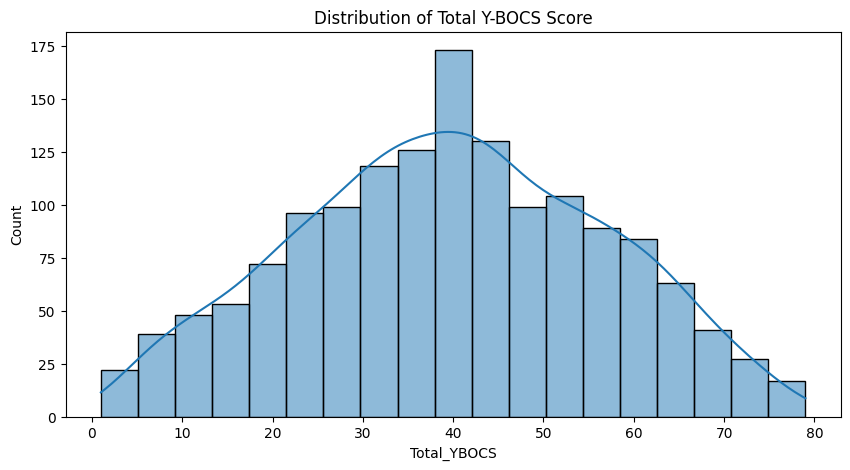

In [3]:
# Check missing values
print("Missing Values:\n", df.isnull().sum())

# Check duplicates
print("\nDuplicate rows:", df.duplicated().sum())

# Basic statistics
print("\nNumerical Summary:")
display(df.describe())

# Target distribution (Severity)
print("\nSeverity Level Distribution:")
print(df['Severity_Level'].value_counts())

# Y-BOCS distribution
plt.figure(figsize=(10,5))
sns.histplot(df['Total_YBOCS'], kde=True)
plt.title('Distribution of Total Y-BOCS Score')
plt.show()

In [4]:
print(df.shape)
print(df.isnull().sum())

(1500, 19)
Age                              0
Gender                           0
Ethnicity                        0
Marital Status                   0
Education Level                  0
OCD Diagnosis Date               0
Duration of Symptoms (months)    0
Previous Diagnoses               0
Family History of OCD            0
Obsession Type                   0
Compulsion Type                  0
Y-BOCS Score (Obsessions)        0
Y-BOCS Score (Compulsions)       0
Depression Diagnosis             0
Anxiety Diagnosis                0
Medications                      0
Diagnosis_Year                   0
Total_YBOCS                      0
Severity_Level                   0
dtype: int64


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ==================== PREPARE DATA ====================
features_to_drop = ['OCD Diagnosis Date', 'Severity_Level', 'Total_YBOCS',
                   'Y-BOCS Score (Obsessions)', 'Y-BOCS Score (Compulsions)']

X = df.drop(columns=features_to_drop, errors='ignore')
y = df['Severity_Level']                    # <-- Using string labels directly

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical features:", categorical_cols)
print("Numerical features:", numerical_cols)

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])

# Random Forest Pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=400,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        class_weight='balanced'   # Helps with class imbalance
    ))
])

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)

# Train the model
rf_pipeline.fit(X_train, y_train)
y_pred = rf_pipeline.predict(X_test)

# Results
print("✅ Random Forest Training Completed!")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Categorical features: ['Gender', 'Ethnicity', 'Marital Status', 'Education Level', 'Previous Diagnoses', 'Obsession Type', 'Compulsion Type', 'Medications']
Numerical features: ['Age', 'Duration of Symptoms (months)', 'Family History of OCD', 'Depression Diagnosis', 'Anxiety Diagnosis', 'Previous_Diagnoses_Count', 'Severity_Code']
✅ Random Forest Training Completed!
Accuracy: 0.9567

Classification Report:
               precision    recall  f1-score   support

     Extreme       0.96      1.00      0.98       203
        Mild       1.00      0.50      0.67        18
    Moderate       1.00      0.97      0.98        29
      Severe       0.91      1.00      0.95        42
 Subclinical       1.00      0.62      0.77         8

    accuracy                           0.96       300
   macro avg       0.97      0.82      0.87       300
weighted avg       0.96      0.96      0.95       300

